In [381]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from IPython.display import display


### PARAMS

In [382]:
T = 60  # Порог 
image_path = "Тестовые изображения/01_apc.tif"

In [383]:
def analyze_image(image_or_path, title="Исходное"):
    """
    Считывает изображение (из пути или объекта),
    строит гистограмму яркости и печатает информацию.
    """
    if isinstance(image_or_path, (str, Path)):
        path = Path(image_or_path)
        if not path.exists():
            raise FileNotFoundError(f"Файл не найден: {path}")
        img = Image.open(path).convert("L")
    elif isinstance(image_or_path, Image.Image):
        img = image_or_path.convert("L")
    elif isinstance(image_or_path, np.ndarray):
        img = Image.fromarray(image_or_path.astype(np.uint8), mode="L")
    else:
        raise TypeError("Ожидается путь, PIL.Image или numpy.ndarray")

    width, height = img.size
    total_pixels = width * height

    # Матрица и гистограмма
    matrix = np.array(img, dtype=np.uint8)
    arr = matrix.ravel()
    hist, _ = np.histogram(arr, bins=np.arange(257))

    # Печать информации
    print(f"Разрешение: {width} × {height} пикселей")
    print(f"Количество пикселей: {total_pixels}")
    print(f"Минимальная яркость: {arr.min()}, максимальная: {arr.max()}, средняя: {arr.mean():.2f}")

    # Гистограмма
    plt.figure()
    plt.bar(range(256), hist, width=3)
    plt.title(f"Гистограмма яркости (0–255) {title}")
    plt.xlabel("Яркость")
    plt.ylabel("Частота")
    plt.xlim(0, 255)
    plt.tight_layout()
    plt.show()

    return {
        "width": width,
        "height": height,
        "total_pixels": total_pixels,
        "histogram": hist,
        "matrix": matrix,
        "image": img
    }

In [384]:
def show_image(matrix, title):
     # гарантируем ndarray uint8
    if hasattr(matrix, "dtype"):
        arr = matrix
    else:
        # если прилетела PIL.Image
        arr = np.array(matrix, dtype=np.uint8)
    
    # Настроим размер вывода (в дюймах, 1 дюйм ≈ 96px)
    plt.figure(figsize=(3, 3))
    plt.imshow(arr, cmap="gray", vmin=0, vmax=255)
    plt.title(title)   # подпись сверху
    plt.axis("off")  # скрыть оси, чтобы был «чистый» вывод

    plt.show()

## 1. Пороговая обработка.

ВЫХОД:
1) Исходное изображение

2) Изображение после пороговой обработки

3) Исходная гистограмма

4) Гистограмма после пороговой обработки

5) График функции поэлементного преобразования

In [385]:
## Пороговая обработка.
def t_porog(name_path, t): 

    path = Path(name_path)
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path}")
    img = Image.open(path).convert("L")
    matrix = np.array(img, dtype=np.uint8)
    N = matrix.shape[0]
    M = matrix.shape[1]
    newMatrix =  np.zeros_like(matrix)

    for i in range(N):
        for j in range(M):
            if(matrix[i][j]<t):
                newMatrix[i][j] = 0
            else:
                newMatrix[i][j] = 255

    x = np.arange(256)                # входные значения яркости
    y = np.where(x < t, 0, 255)       # выход по правилу

    plt.figure()
    plt.plot(x, y, drawstyle="steps-post", color="red")
    plt.title(f"Функция поэлементного преобразования (T={t})")
    plt.xlabel("Входная яркость (x)")
    plt.ylabel("Выходная яркость g(x)")
    plt.grid(True)
    plt.show()
    
    return Image.fromarray(newMatrix, mode="L")


Разрешение: 512 × 512 пикселей
Количество пикселей: 262144
Минимальная яркость: 12, максимальная: 215, средняя: 127.19


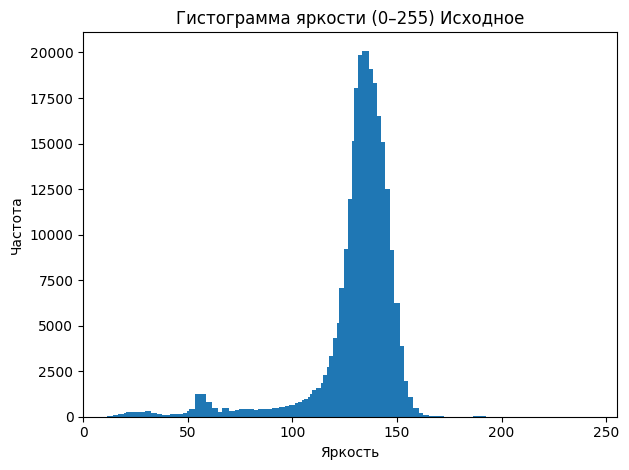

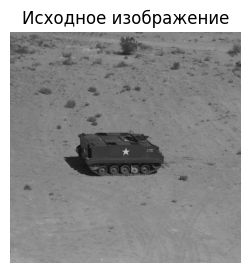

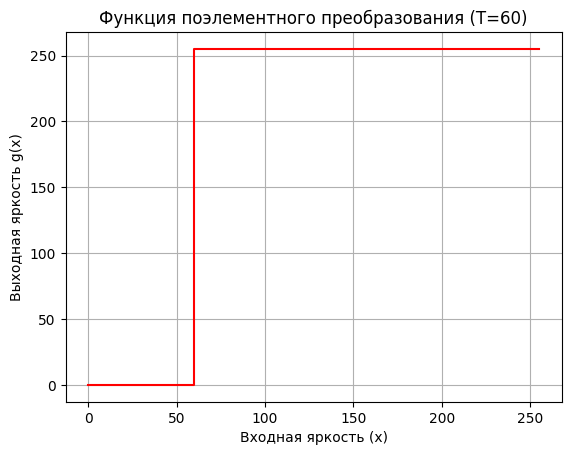

C:\Users\boga4\AppData\Local\Temp\ipykernel_22960\3918036331.py:31: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(newMatrix, mode="L")


Разрешение: 512 × 512 пикселей
Количество пикселей: 262144
Минимальная яркость: 0, максимальная: 255, средняя: 244.10


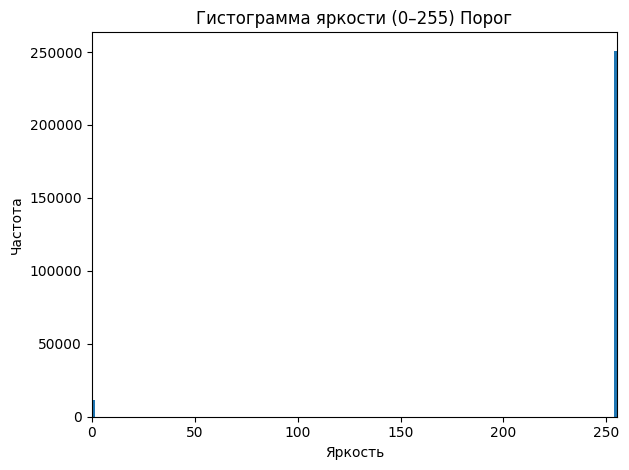

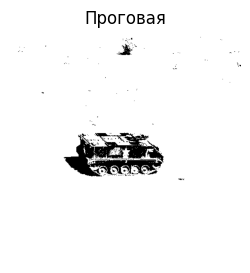

In [386]:
info = analyze_image(image_path)
show_image(info["matrix"], "Исходное изображение")


porogimg = t_porog(image_path, T)
infoporog = analyze_image(porogimg, title="Порог")
show_image(infoporog["matrix"], "Проговая")


## 2. Контрастирование

ВЫХОД:
1) Исходное изображение

2) Контрастированное изображение

3) Исходная гистограмма

4) Гистограмма после контрастирования

5) График функции поэлементного преобразования

In [387]:
def contrast(name_path, gmin=0, gmax=255):

    path = Path(name_path)
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path}")
    img = Image.open(path).convert("L")
    matrix = np.array(img, dtype=np.uint8)

    a = (gmax - gmin) / (matrix.max() - matrix.min())
    b = (gmin * matrix.max() - gmax* matrix.min()) / (matrix.max() - matrix.min())
    #b = (gmin * max(matrix) - gmax* min(matrix)) / max(matrix) - min(matrix)
    N = matrix.shape[0]
    M = matrix.shape[1]
    newMatrix = np.zeros_like(matrix)
    for i in range(N):
        for j in range(M):
            newMatrix[i][j] = a * matrix[i][j] + b
    return Image.fromarray(newMatrix, mode="L")



Разрешение: 512 × 512 пикселей
Количество пикселей: 262144
Минимальная яркость: 12, максимальная: 215, средняя: 127.19


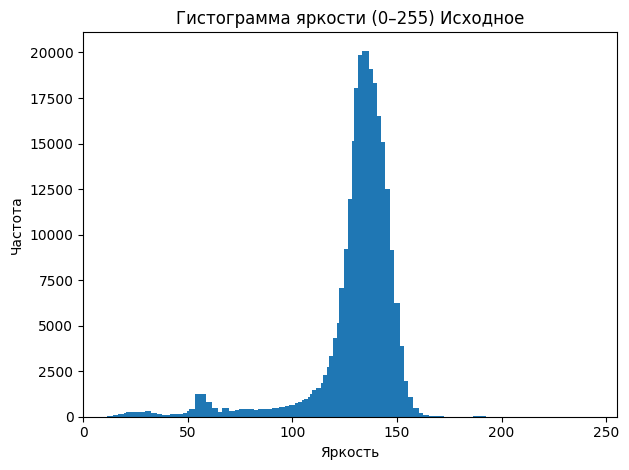

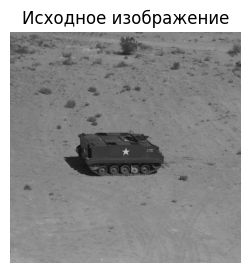

C:\Users\boga4\AppData\Local\Temp\ipykernel_22960\3175422353.py:10: RuntimeWarning: overflow encountered in scalar multiply
  b = (gmin * matrix.max() - gmax* matrix.min()) / (matrix.max() - matrix.min())
C:\Users\boga4\AppData\Local\Temp\ipykernel_22960\3175422353.py:18: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(newMatrix, mode="L")


Разрешение: 512 × 512 пикселей
Количество пикселей: 262144
Минимальная яркость: 2, максимальная: 31, средняя: 18.85


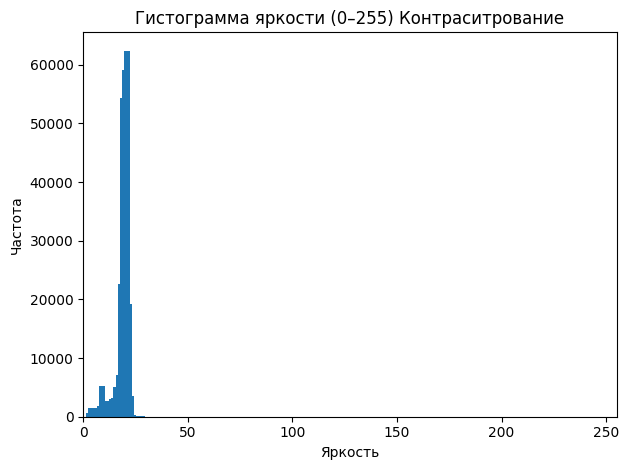

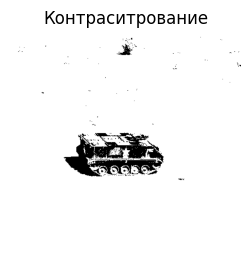

In [388]:
info = analyze_image(image_path)
show_image(info["matrix"], "Исходное изображение")


contrastimg = contrast(image_path, 100, 129)
infocontrast = analyze_image(contrastimg, title="Контраситрование")
show_image(infoporog["matrix"], "Контраситрование")

## 3. Эквализация

1) Исходное изображение

2) Изображение после эквализации (стандратной и самописной)

3) График интегральной функции распределения яркости (до и после обработки)

4) Гистограмма исходного изображения

5) Гистограмма изображения после эквализации (стандартной и самописной)

6) График функции поэлементного преобразования

7) Выдать в консоль функцией типа print массивы гистограммы исходного изображения

и границ интервалов этой гистограммы, выданные функцией

hist, bins = histogram(...

Продемонстрировать, что массив границ интервалов bins

начинается с нуля и содержит числа 0 1 2 3 .. 255 256